# SOKE Skeleton Visualization (SMPL-X + Camera Projection)

SMPL-X body model을 사용해서 axis-angle rotation → 3D joints → 2D projection

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline

import sys
sys.path.insert(0, '.')

## 1. 경로 설정

In [15]:
# SMPL-X 모델 경로
SMPLX_MODEL_PATH = '/home/user/Projects/research/SOKE/deps/smpl_models/smplx/SMPLX_NEUTRAL.npz'  # SMPLX_NEUTRAL.npz 등

# 데이터 경로
DATA_ROOT = '/home/user/Projects/research/SOKE/data/How2Sign'
MEAN_PATH = '/home/user/Projects/research/SOKE/data/CSL-Daily/mean.pt'
STD_PATH = '/home/user/Projects/research/SOKE/data/CSL-Daily/std.pt'

## 2. Visualizer 로드

In [16]:
from utils.skeleton_smplx import SOKEVisualizer

viz = SOKEVisualizer(SMPLX_MODEL_PATH, device='cuda')

SMPL-X loaded: /home/user/Projects/research/SOKE/deps/smpl_models/smplx/SMPLX_NEUTRAL.npz (device: cuda)


## 3. 데이터 로드

In [17]:
# Mean/Std 로드
mean = torch.load(MEAN_PATH)
std = torch.load(STD_PATH)

# SOKE 필터링 (179 -> 133)
mean = mean[(3 + 3 * 11):]
mean = torch.cat([mean[:-20], mean[-10:]], dim=0)
std = std[(3 + 3 * 11):]
std = torch.cat([std[:-20], std[-10:]], dim=0)

print(f"Feature dim: {mean.shape[0]}")

Feature dim: 133


In [18]:
from mGPT.data.humanml import H2SMotionDatasetVQ

dataset = H2SMotionDatasetVQ(
    data_root=DATA_ROOT,
    split='train',
    mean=mean,
    std=std,
    max_motion_length=400,
    min_motion_length=40,
    win_size=None,
    dataset_name='how2sign',
)

print(f"Dataset size: {len(dataset)}")

train--loading how2sign annotations... 30711


100%|██████████| 30711/30711 [01:25<00:00, 359.03it/s]

Data loading done. All: 30684, How2Sign: 30684, CSL: 0, Phoenix: 0
Dataset size: 30684


In [19]:
# 샘플 로드
SAMPLE_IDX = 0

sample = dataset[SAMPLE_IDX]
text = sample[0]
motion = sample[1].numpy()  # (T, 133)
name = sample[3]

print(f"Sample: {name}")
print(f"Text: {text}")
print(f"Motion shape: {motion.shape}")

Sample: --7E2sU6zP4_10-5-rgb_front
Text: And I call them decorative elements because basically all they're meant to do is to enrich and color the page.
Motion shape: (364, 133)


## 4. 단일 프레임 시각화

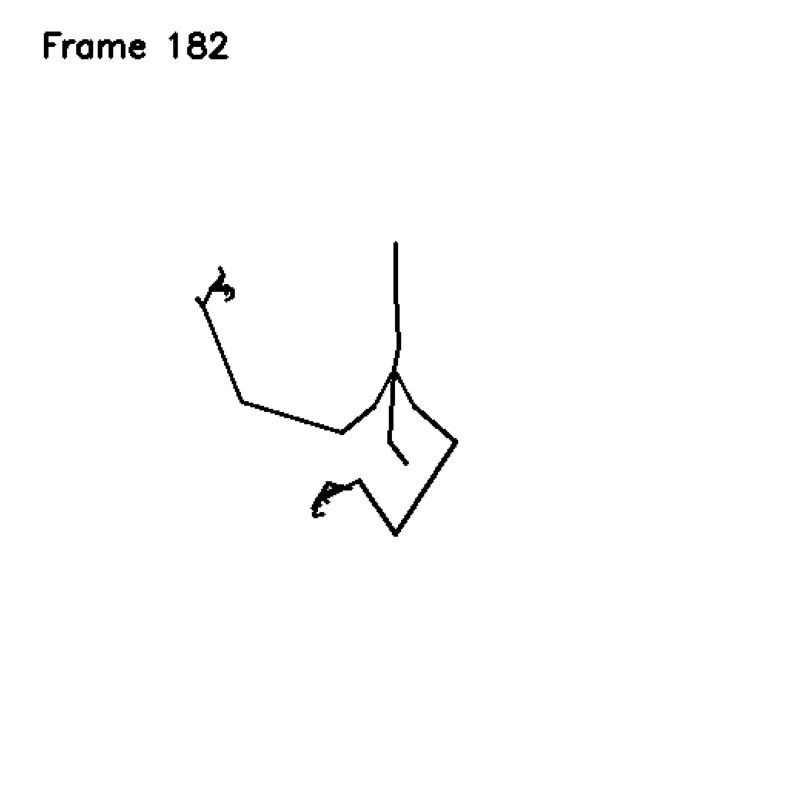

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [20]:
# 중간 프레임 시각화
frame_idx = len(motion) // 2
pose = motion[frame_idx]

viz.plot_frame(pose, title=f'Frame {frame_idx}', z_offset=2.5)

## 5. 여러 프레임 시각화

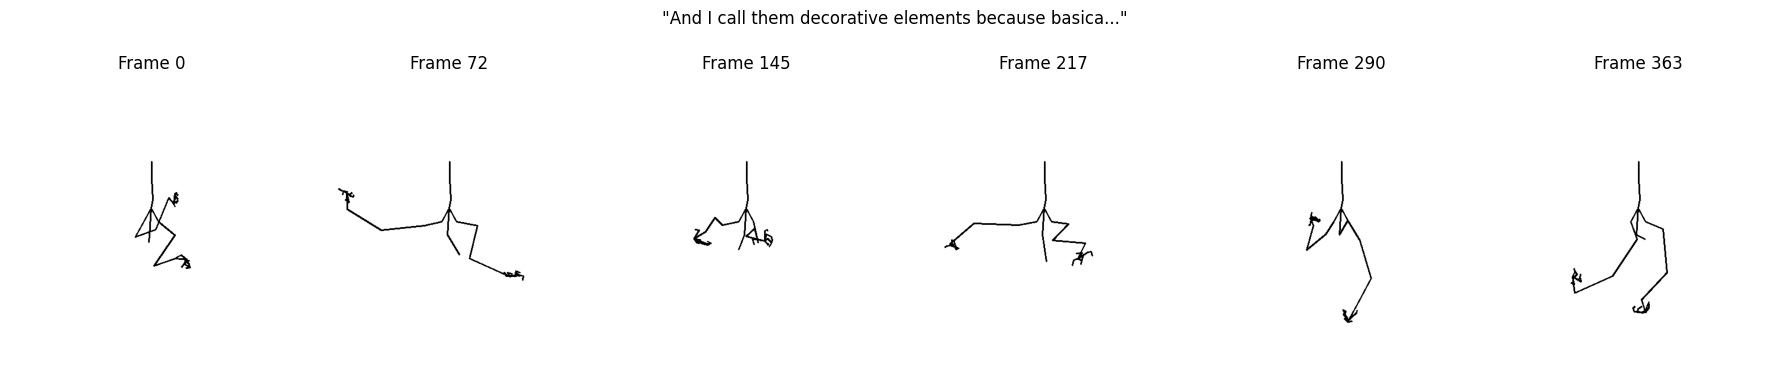

In [21]:
n_frames = 6
indices = np.linspace(0, len(motion)-1, n_frames, dtype=int)

fig, axes = plt.subplots(1, n_frames, figsize=(3*n_frames, 4))

for ax, idx in zip(axes, indices):
    frame = viz.plot_frame(motion[idx], show=False)
    ax.imshow(frame[:,:,::-1])
    ax.set_title(f'Frame {idx}')
    ax.axis('off')

plt.suptitle(f'"{text[:50]}..."', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Pred vs GT 비교

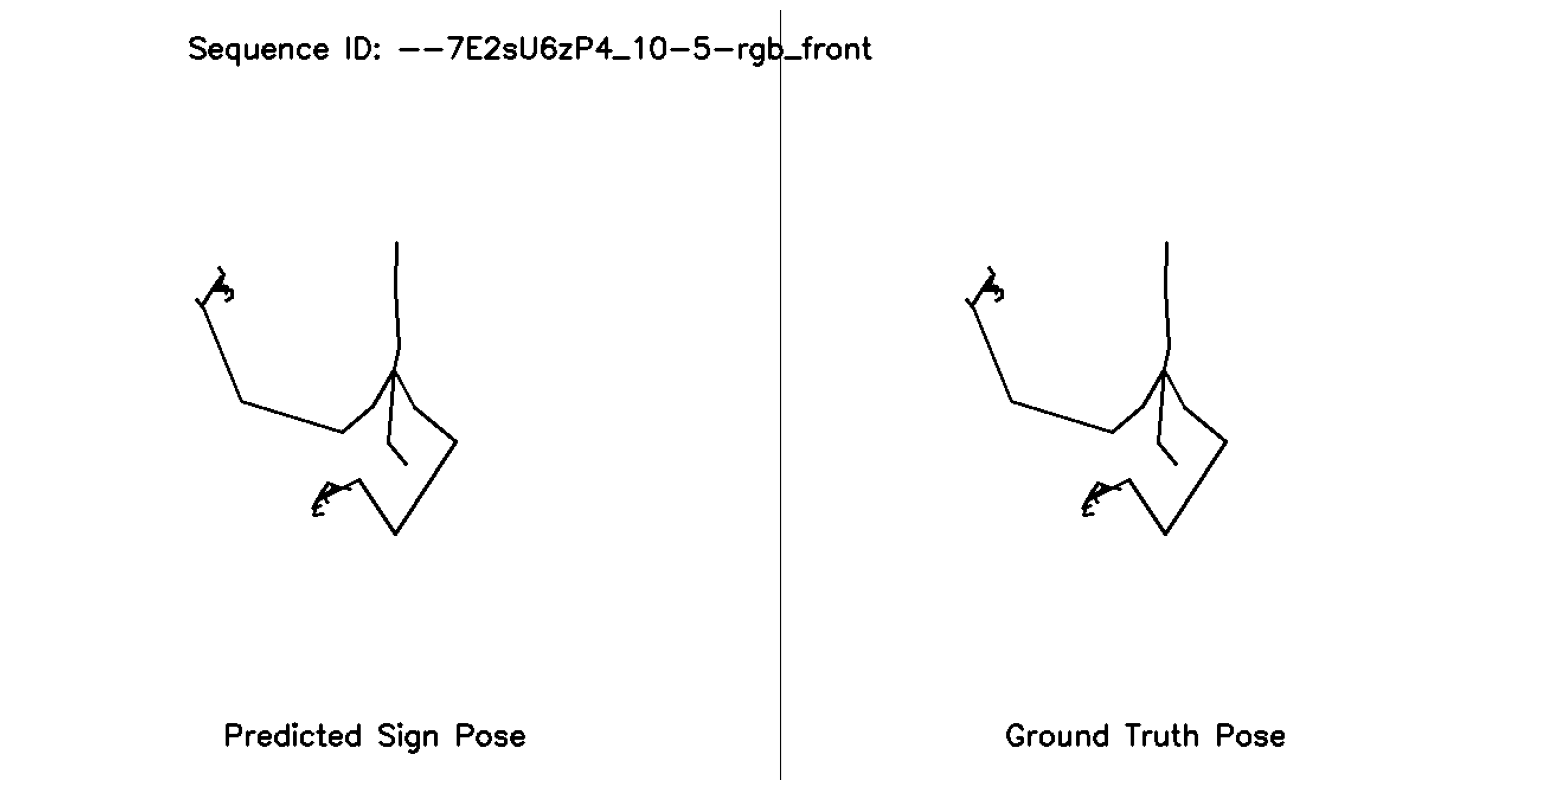

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [22]:
# 같은 데이터로 테스트 (실제로는 model output 사용)
pred = motion[frame_idx]
gt = motion[frame_idx]

viz.plot_comparison(pred, gt, title=name)

## 7. 비디오 생성

In [23]:
# 단일 모션 비디오
viz.create_video(motion[:100], 'skeleton_pred.mp4', fps=25)

# Pred vs GT 비교 비디오
# viz.create_video(pred_motion, 'skeleton_compare.mp4', reference=gt_motion, title=name)

Creating video: 100 frames @ 25 fps
  50/100
  100/100
Saved: skeleton_pred.mp4


## 8. 애니메이션 (Jupyter)

In [24]:
# 처음 50프레임
anim = viz.animate(motion[:50], fps=15)
anim

## 9. 다른 샘플

In [ ]:
import random

idx = random.randint(0, len(dataset)-1)
sample = dataset[idx]
motion2 = sample[1].numpy()
text2 = sample[0]
name2 = sample[3]

print(f"Sample: {name2}")
print(f"Text: {text2}")

viz.plot_frame(motion2[len(motion2)//2], title=name2)